<a href="https://colab.research.google.com/github/ashen-pabasara/CNN-credit-card-fraud-detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup the Environment**

In [ ]:
# Import Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten


**Load the Dataset (from Kaggle)**

In [ ]:
# Enable Kaggle API
!pip install kaggle

# Upload Kaggle API key (download kaggle.json from your Kaggle account)
from google.colab import files
files.upload()

# Move it to correct directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud

# Unzip dataset
!unzip creditcardfraud.zip


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
  0% 0.00/66.0M [00:00<?, ?B/s]
100% 66.0M/66.0M [00:00<00:00, 1.45GB/s]
Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [ ]:

df = pd.read_csv("creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Dataset Summary**

In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Scaling**

In [ ]:
scaler = StandardScaler()
df['normAmount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['normTime'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df = df.drop(['Time', 'Amount'], axis=1)


**EDA**

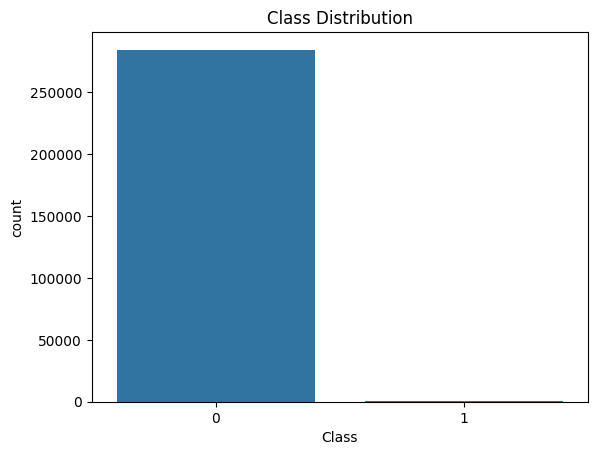

Class
0    284315
1       492
Name: count, dtype: int64
Fraud ratio: 0.0017304750013189597


In [ ]:
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

fraud_count = df['Class'].value_counts()
print(fraud_count)
print("Fraud ratio:", fraud_count[1]/fraud_count[0])


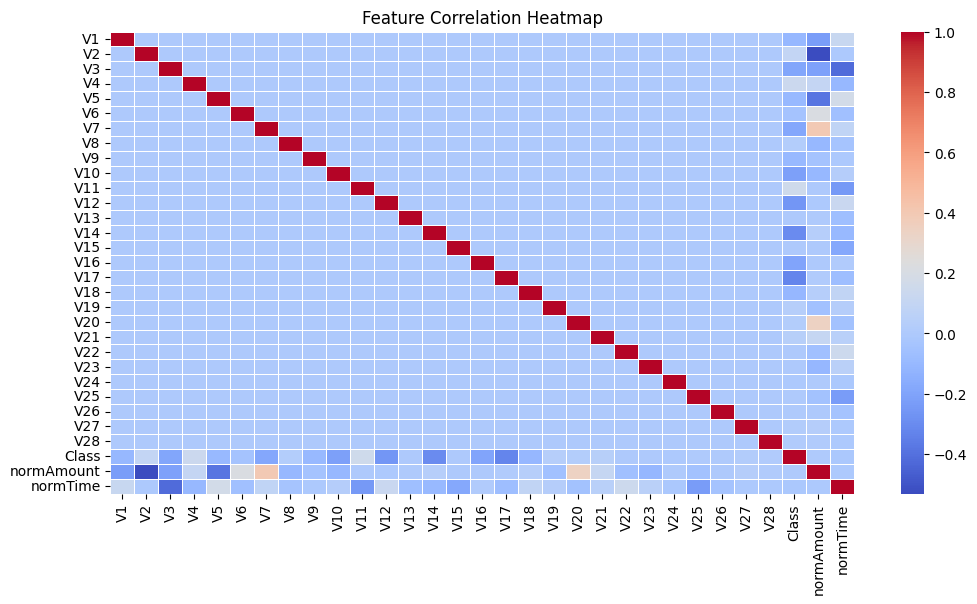

In [ ]:
corr = df.corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


**Split Data**

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


**Handle Class Imbalance**

In [ ]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)


**CNN Model Building**

In [ ]:
X_train_cnn = np.expand_dims(X_train, axis=2)
X_test_cnn = np.expand_dims(X_test, axis=2)
X_res_cnn = np.expand_dims(X_res, axis=2)


In [ ]:
def build_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))

    model.add(Conv1D(filters=64, kernel_size=2, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:

input_shape = (X_train.shape[1], 1)
cnn_model = build_cnn(input_shape)

# Show model architecture
cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 29, 32)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 13, 64)         │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,961 (113.13 KB)

 Trainable params: 28,961 (113.13 KB)

 Non-trainable params: 0 (0.00 B)

**Train and Evaluate**

In [ ]:
# Version A – Without SMOTE
cnn_no_smote = build_cnn((X_train_cnn.shape[1], 1))
history_no_smote = cnn_no_smote.fit(X_train_cnn, y_train, epochs=10, batch_size=2048, validation_data=(X_test_cnn, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 26s 195ms/step - accuracy: 0.9375 - loss: 0.1896 - val_accuracy: 0.9983 - val_loss: 0.0246
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - accuracy: 0.9983 - loss: 0.0196 - val_accuracy: 0.9991 - val_loss: 0.0066
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - accuracy: 0.9990 - loss: 0.0070 - val_accuracy: 0.9993 - val_loss: 0.0043
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.9992 - loss: 0.0051 - val_accuracy: 0.9993 - val_loss: 0.0037
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.9993 - loss: 0.0045 - val_accuracy: 0.9993 - val_loss: 0.0034
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.9992 - loss: 0.0043 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9993 - val_loss: 0.0033
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.9994 - loss: 0.0036 

In [ ]:
# Version B – With SMOTE
cnn_smote = build_cnn((X_res_cnn.shape[1], 1))
history_smote = cnn_smote.fit(X_res_cnn, y_res, epochs=10, batch_size=2048, validation_data=(X_test_cnn, y_test))


Epoch 1/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.8738 - loss: 0.2569 - val_accuracy: 0.9788 - val_loss: 0.0789
Epoch 2/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - accuracy: 0.9594 - loss: 0.1025 - val_accuracy: 0.9827 - val_loss: 0.0602
Epoch 3/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.9743 - loss: 0.0692 - val_accuracy: 0.9820 - val_loss: 0.0583
Epoch 4/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.9812 - loss: 0.0524 - val_accuracy: 0.9879 - val_loss: 0.0414
Epoch 5/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - accuracy: 0.9858 - loss: 0.0411 - val_accuracy: 0.9892 - val_loss: 0.0359
Epoch 6/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.9890 - loss: 0.0329 - val_accuracy: 0.9905 - val_loss: 0.0312
Epoch 7/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.9910 - loss: 0.0276 - val_accuracy: 0.9932 - val_loss: 0.0239
Epoch 8/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.9921 - loss: 0.0245 - 

**Model Evaluation**

In [ ]:
# Predict
y_pred_no_smote = (cnn_no_smote.predict(X_test_cnn) > 0.5).astype(int)
y_pred_smote = (cnn_smote.predict(X_test_cnn) > 0.5).astype(int)

# Evaluate
print("=== Without SMOTE ===")
print(classification_report(y_test, y_pred_no_smote))
print(confusion_matrix(y_test, y_pred_no_smote))

print("\n=== With SMOTE ===")
print(classification_report(y_test, y_pred_smote))
print(confusion_matrix(y_test, y_pred_smote))


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
=== Without SMOTE ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

[[56847    17]
 [   19    79]]

=== With SMOTE ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.22      0.90      0.36        98

    accuracy                           0.99     56962
   macro avg       0.61      0.95      0.68     56962
weighted avg       1.00      0.99      1.00     56962

[[56556   308]
 [   10    88]]


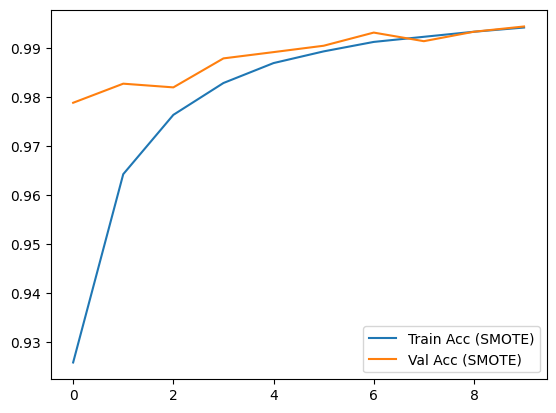

In [ ]:
# Visualize Training
plt.plot(history_smote.history['accuracy'], label='Train Acc (SMOTE)')
plt.plot(history_smote.history['val_accuracy'], label='Val Acc (SMOTE)')
plt.legend()
plt.show()


**Save Models**

In [ ]:
cnn_smote.save('/content/drive/MyDrive/cnn_fraud_smote.h5')
cnn_no_smote.save('/content/drive/MyDrive/cnn_fraud_no_smote.h5')
